Assignment 4 - ML Lab

## Theory Background

### Logistic Regression
Logistic Regression is a probabilistic classification algorithm used for binary classification problems. It models the probability that a sample belongs to a particular class using the sigmoid function. A threshold such as 0.5 is used to convert probability into a class label.

It minimizes log-loss and can use L1 or L2 regularization to control model complexity. The hyperparameter `C` controls inverse regularization strength.

### Support Vector Machine
SVM is a margin-based classifier that finds an optimal hyperplane separating two classes by maximizing the margin. Kernel functions such as linear, polynomial, RBF, and sigmoid allow SVM to learn non-linear boundaries.

The hyperparameter `C` controls the margin-versus-misclassification trade-off, while `gamma` controls the influence of a single training point.

## 1. Import Libraries

In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score, train_test_split
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', None)

## 2. Load the Dataset

In [4]:
base_dir = Path.cwd()
dataset_path = base_dir.parent / 'Assignment-2' / 'dataset' / 'spambase_csv.xls'

if not dataset_path.exists():
    dataset_path = Path(r'd:\\Semester-5\\Machine Learning - Lab\\Assignment-2\\dataset\\spambase_csv.csv')

df = pd.read_csv(dataset_path)
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'd:\\\\Semester-5\\\\Machine Learning - Lab\\\\Assignment-2\\\\dataset\\\\spambase_csv.csv'

## 3. Basic Data Inspection

In [5]:
print('Dataset shape:', df.shape)
print('Feature count:', df.shape[1] - 1)
print('Missing values:', int(df.isna().sum().sum()))
print('Target column: class')
display(df.head())
display(df['class'].value_counts().rename(index={0: 'Ham', 1: 'Spam'}).to_frame('count'))

NameError: name 'df' is not defined

## 4. Exploratory Data Analysis

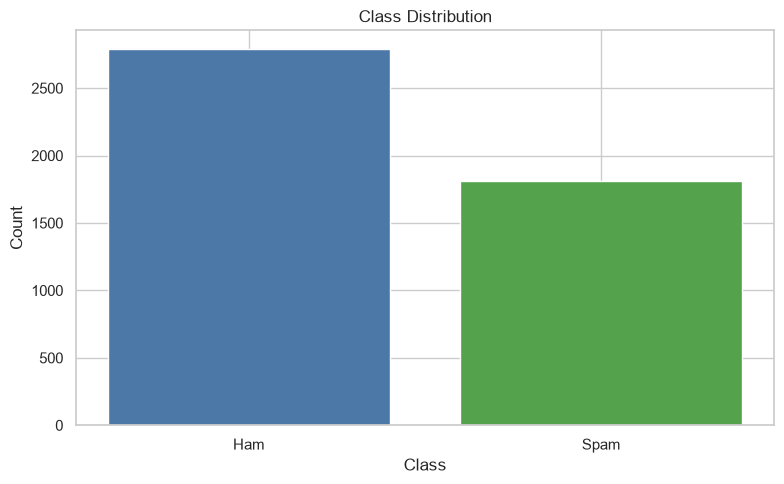

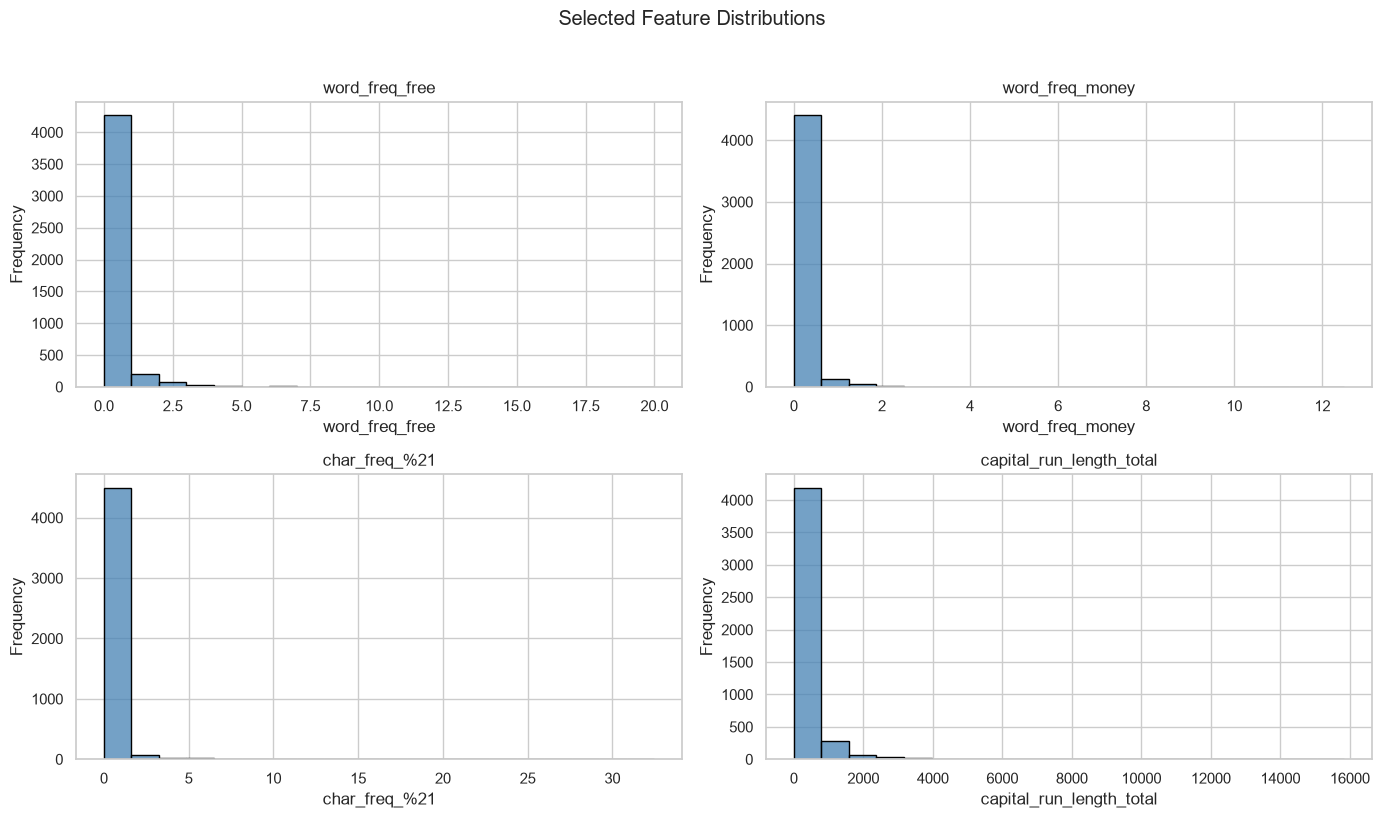

In [8]:
class_counts = df['class'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(['Ham', 'Spam'], class_counts.values, color=['#4C78A8', '#54A24B'])
ax.set_title('Class Distribution')
ax.set_xlabel('Class')
ax.set_ylabel('Count')
plt.tight_layout()

sample_features = ['word_freq_free', 'word_freq_money', 'char_freq_%21', 'capital_run_length_total']
fig, hist_axes = plt.subplots(2, 2, figsize=(14, 8))
hist_axes = hist_axes.ravel()

for axis, feature in zip(hist_axes, sample_features):
    sns.histplot(df[feature], bins=20, color='steelblue', edgecolor='black', ax=axis)
    axis.set_title(feature)
    axis.set_xlabel(feature)
    axis.set_ylabel('Frequency')

plt.suptitle('Selected Feature Distributions', y=1.02)
plt.tight_layout()

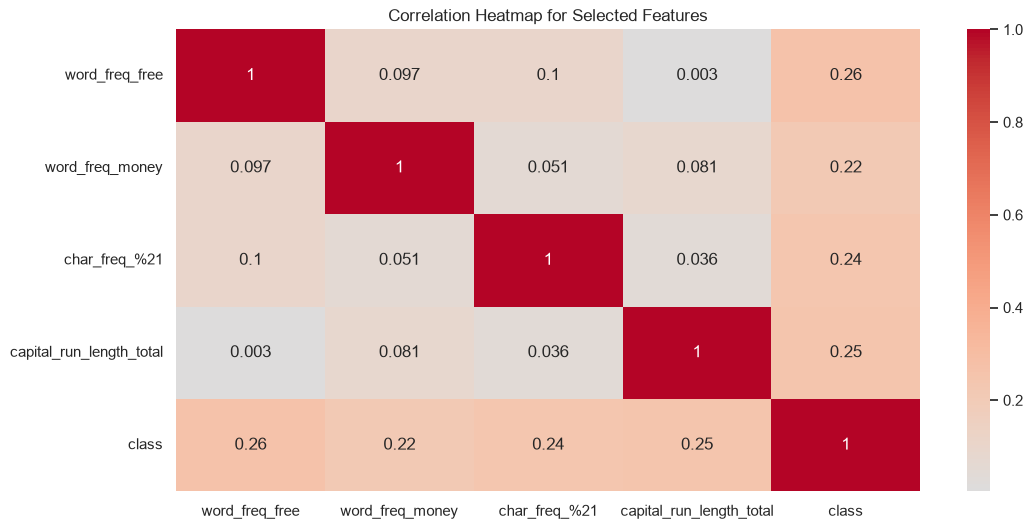

In [9]:
correlation_sample = df[['word_freq_free', 'word_freq_money', 'char_freq_%21', 'capital_run_length_total', 'class']].corr()
sns.heatmap(correlation_sample, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap for Selected Features')
plt.show()

## 5. Prepare Features and Target

In [10]:
target_column = 'class'
X = df.drop(columns=[target_column])
y = df[target_column]

print('Feature matrix shape:', X.shape)
print('Target shape:', y.shape)

Feature matrix shape: (4601, 57)
Target shape: (4601,)


## 6. Train-Test Split and Preprocessing

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

preprocessor = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print('Train size:', X_train.shape, 'Test size:', X_test.shape)

Train size: (3680, 57) Test size: (921, 57)


## 7. Baseline Logistic Regression Model

In [12]:
baseline_lr = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', LogisticRegression(max_iter=2000, random_state=42)),
])

start_time = time.time()
baseline_lr.fit(X_train, y_train)
baseline_lr_time = time.time() - start_time

y_pred_lr_base = baseline_lr.predict(X_test)
y_prob_lr_base = baseline_lr.predict_proba(X_test)[:, 1]

baseline_lr_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_lr_base),
    'Precision': precision_score(y_test, y_pred_lr_base),
    'Recall': recall_score(y_test, y_pred_lr_base),
    'F1 Score': f1_score(y_test, y_pred_lr_base),
    'ROC AUC': roc_auc_score(y_test, y_prob_lr_base),
    'Training Time (s)': baseline_lr_time,
}

pd.DataFrame([baseline_lr_metrics])

,Accuracy,Precision,Recall,F1 Score,ROC AUC,Training Time (s)
0,0.929425,0.920904,0.898072,0.909344,0.970196,0.050001


              precision    recall  f1-score   support

         Ham       0.93      0.95      0.94       558
        Spam       0.92      0.90      0.91       363

    accuracy                           0.93       921
   macro avg       0.93      0.92      0.93       921
weighted avg       0.93      0.93      0.93       921



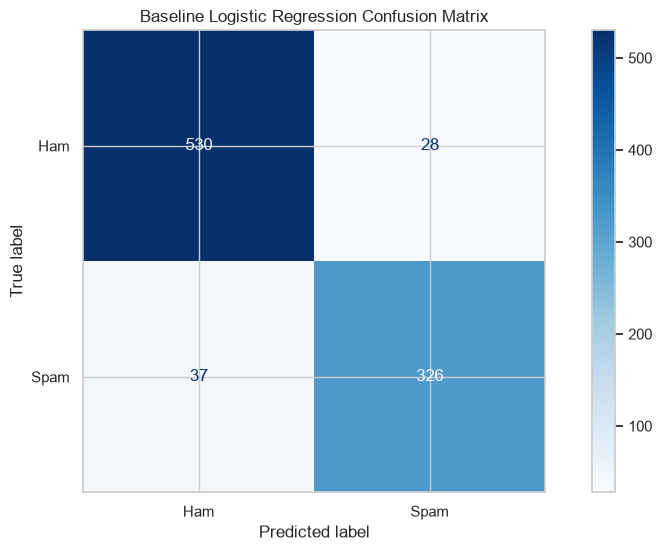

In [13]:
print(classification_report(y_test, y_pred_lr_base, target_names=['Ham', 'Spam']))
cm_lr_base = confusion_matrix(y_test, y_pred_lr_base)
ConfusionMatrixDisplay(cm_lr_base, display_labels=['Ham', 'Spam']).plot(cmap='Blues')
plt.title('Baseline Logistic Regression Confusion Matrix')
plt.show()

## 8. Tune Logistic Regression Hyperparameters

Grid search evaluates L1 and L2 regularization with different values of `C` and solvers.

In [14]:
lr_pipeline = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', LogisticRegression(max_iter=5000, random_state=42)),
])

lr_param_grid = {
    'model__penalty': ['l1', 'l2'],
    'model__C': [0.01, 0.1, 1, 10, 100],
    'model__solver': ['liblinear', 'saga'],
}

lr_grid = GridSearchCV(
    lr_pipeline,
    lr_param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0,
)

start_time = time.time()
lr_grid.fit(X_train, y_train)
lr_tuning_time = time.time() - start_time

print('Best Logistic Regression Parameters:', lr_grid.best_params_)
print('Best CV Accuracy:', lr_grid.best_score_)

best_lr = lr_grid.best_estimator_
y_pred_lr = best_lr.predict(X_test)
y_prob_lr = best_lr.predict_proba(X_test)[:, 1]

lr_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_lr),
    'Precision': precision_score(y_test, y_pred_lr),
    'Recall': recall_score(y_test, y_pred_lr),
    'F1 Score': f1_score(y_test, y_pred_lr),
    'ROC AUC': roc_auc_score(y_test, y_prob_lr),
    'Training Time (s)': lr_tuning_time,
}

pd.DataFrame([{'Best Parameters': lr_grid.best_params_, 'Best CV Accuracy': lr_grid.best_score_}])

c:\Users\sathi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\sathi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Best Logistic Regression Parameters: {'model__C': 100, 'model__penalty': 'l1', 'model__solver': 'liblinear'}
Best CV Accuracy: 0.9266304347826088


,Best Parameters,Best CV Accuracy
0,"{'model__C': 100, 'model__penalty': 'l1', 'mod...",0.92663


## 9. Logistic Regression Performance

In [15]:
logistic_performance = pd.DataFrame([lr_metrics])
logistic_performance

,Accuracy,Precision,Recall,F1 Score,ROC AUC,Training Time (s)
0,0.926167,0.920228,0.889807,0.904762,0.96786,46.165588


              precision    recall  f1-score   support

         Ham       0.93      0.95      0.94       558
        Spam       0.92      0.89      0.90       363

    accuracy                           0.93       921
   macro avg       0.93      0.92      0.92       921
weighted avg       0.93      0.93      0.93       921



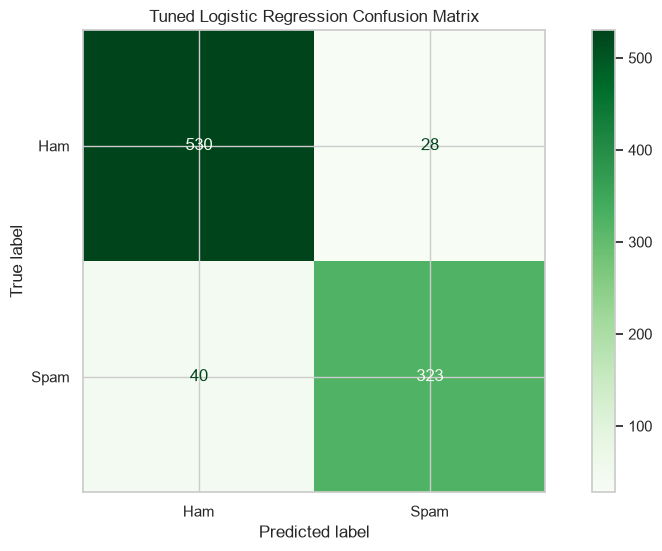

In [16]:
print(classification_report(y_test, y_pred_lr, target_names=['Ham', 'Spam']))
cm_lr = confusion_matrix(y_test, y_pred_lr)
ConfusionMatrixDisplay(cm_lr, display_labels=['Ham', 'Spam']).plot(cmap='Greens')
plt.title('Tuned Logistic Regression Confusion Matrix')
plt.show()

## 10. Train SVM with Multiple Kernels

The following models compare linear, polynomial, RBF, and sigmoid kernels.

In [17]:
svm_kernel_results = []
svm_models = {}
kernel_configs = [
    ('linear', {'kernel': 'linear', 'C': 1.0, 'gamma': 'scale'}),
    ('poly', {'kernel': 'poly', 'C': 1.0, 'gamma': 'scale', 'degree': 3}),
    ('rbf', {'kernel': 'rbf', 'C': 1.0, 'gamma': 'scale'}),
    ('sigmoid', {'kernel': 'sigmoid', 'C': 1.0, 'gamma': 'scale'}),
]

for kernel_name, params in kernel_configs:
    svm_pipeline = Pipeline(steps=[
        ('preprocess', preprocessor),
        ('model', SVC(**params)),
    ])
    start_time = time.time()
    svm_pipeline.fit(X_train, y_train)
    fit_time = time.time() - start_time
    predictions = svm_pipeline.predict(X_test)

    svm_models[kernel_name] = svm_pipeline
    svm_kernel_results.append({
        'Kernel': kernel_name.capitalize(),
        'Accuracy': accuracy_score(y_test, predictions),
        'F1 Score': f1_score(y_test, predictions),
        'Training Time (s)': fit_time,
    })

svm_kernel_results_df = pd.DataFrame(svm_kernel_results)
svm_kernel_results_df

,Kernel,Accuracy,F1 Score,Training Time (s)
0,Linear,0.929425,0.909344,0.367513
1,Poly,0.779587,0.621974,0.268854
2,Rbf,0.927253,0.905501,0.171830
3,Sigmoid,0.884908,0.852778,0.218482


## 11. Tune SVM Hyperparameters

Grid search evaluates kernel choice, `C`, `gamma`, and polynomial degree.

In [18]:
svm_pipeline = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', SVC()),
])

svm_param_grid = [
    {
        'model__kernel': ['linear'],
        'model__C': [0.1, 1, 10, 100],
        'model__gamma': ['scale', 'auto'],
    },
    {
        'model__kernel': ['poly'],
        'model__C': [0.1, 1, 10, 100],
        'model__gamma': ['scale', 'auto'],
        'model__degree': [2, 3, 4],
    },
    {
        'model__kernel': ['rbf', 'sigmoid'],
        'model__C': [0.1, 1, 10, 100],
        'model__gamma': ['scale', 'auto'],
    },
]

svm_grid = GridSearchCV(
    svm_pipeline,
    svm_param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0,
)

start_time = time.time()
svm_grid.fit(X_train, y_train)
svm_tuning_time = time.time() - start_time

print('Best SVM Parameters:', svm_grid.best_params_)
print('Best CV Accuracy:', svm_grid.best_score_)

best_svm = svm_grid.best_estimator_
y_pred_svm = best_svm.predict(X_test)

svm_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_svm),
    'Precision': precision_score(y_test, y_pred_svm),
    'Recall': recall_score(y_test, y_pred_svm),
    'F1 Score': f1_score(y_test, y_pred_svm),
    'Training Time (s)': svm_tuning_time,
}

pd.DataFrame([{'Best Parameters': svm_grid.best_params_, 'Best CV Accuracy': svm_grid.best_score_}])

Best SVM Parameters: {'model__C': 10, 'model__gamma': 'scale', 'model__kernel': 'rbf'}
Best CV Accuracy: 0.9361413043478262


,Best Parameters,Best CV Accuracy
0,"{'model__C': 10, 'model__gamma': 'scale', 'mod...",0.936141


## 12. SVM Performance

In [19]:
svm_performance = pd.DataFrame([svm_metrics])
svm_performance

,Accuracy,Precision,Recall,F1 Score,Training Time (s)
0,0.920738,0.914286,0.881543,0.897616,24.796178


              precision    recall  f1-score   support

         Ham       0.92      0.95      0.94       558
        Spam       0.91      0.88      0.90       363

    accuracy                           0.92       921
   macro avg       0.92      0.91      0.92       921
weighted avg       0.92      0.92      0.92       921



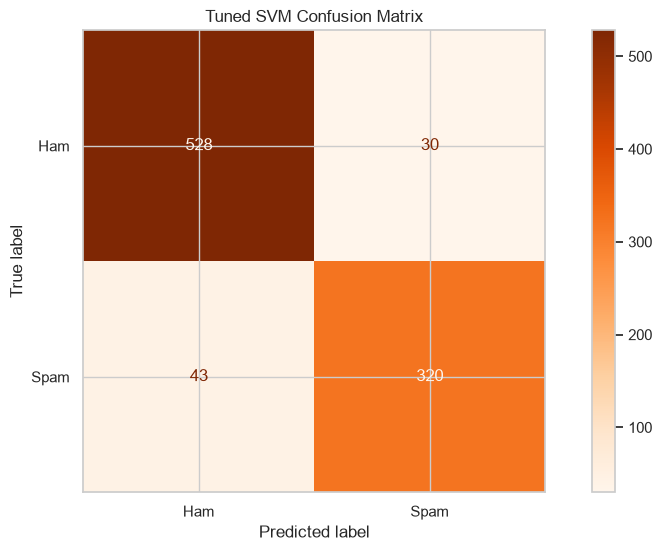

In [20]:
print(classification_report(y_test, y_pred_svm, target_names=['Ham', 'Spam']))
cm_svm = confusion_matrix(y_test, y_pred_svm)
ConfusionMatrixDisplay(cm_svm, display_labels=['Ham', 'Spam']).plot(cmap='Oranges')
plt.title('Tuned SVM Confusion Matrix')
plt.show()

## 13. 5-Fold Cross-Validation

The models below are evaluated using 5-fold stratified cross-validation on the training data.

In [21]:
lr_cv_scores = cross_val_score(best_lr, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
svm_cv_scores = cross_val_score(best_svm, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)

cv_results = pd.DataFrame({
    'Fold': [f'Fold {i}' for i in range(1, 6)] + ['Average'],
    'Logistic Regression': list(np.round(lr_cv_scores, 4)) + [round(lr_cv_scores.mean(), 4)],
    'SVM': list(np.round(svm_cv_scores, 4)) + [round(svm_cv_scores.mean(), 4)],
})
cv_results

,Fold,Logistic Regression,SVM
0,Fold 1,0.9443,0.9429
1,Fold 2,0.9253,0.9457
2,Fold 3,0.9348,0.9334
3,Fold 4,0.9117,0.9307
4,Fold 5,0.9171,0.9280
5,Average,0.9266,0.9361


## 14. Hyperparameter Tuning Summary

In [22]:
tuning_summary = pd.DataFrame([
    {'Model': 'Logistic Regression', 'Search Method': 'Grid Search', 'Best Parameters': lr_grid.best_params_, 'Best CV Accuracy': lr_grid.best_score_},
    {'Model': 'SVM', 'Search Method': 'Grid Search', 'Best Parameters': svm_grid.best_params_, 'Best CV Accuracy': svm_grid.best_score_},
])
tuning_summary

,Model,Search Method,Best Parameters,Best CV Accuracy
0,Logistic Regression,Grid Search,"{'model__C': 100, 'model__penalty': 'l1', 'mod...",0.926630
1,SVM,Grid Search,"{'model__C': 10, 'model__gamma': 'scale', 'mod...",0.936141


## 15. Comparative Analysis

### Observations
- Identify the best-performing classifier by comparing test accuracy, F1 score, and cross-validation mean.
- Regularization in Logistic Regression helps control overfitting. Smaller `C` gives stronger regularization.
- SVM kernel choice affects the decision boundary. Linear kernels are simple, while RBF and polynomial kernels capture non-linear structure.
- Bias-variance trade-off can be seen in how model complexity changes with tuning.

In [23]:
comparison_table = pd.DataFrame([
    {'Criterion': 'Accuracy', 'Logistic Regression': lr_metrics['Accuracy'], 'SVM': svm_metrics['Accuracy']},
    {'Criterion': 'F1 Score', 'Logistic Regression': lr_metrics['F1 Score'], 'SVM': svm_metrics['F1 Score']},
    {'Criterion': 'Training Time (s)', 'Logistic Regression': lr_metrics['Training Time (s)'], 'SVM': svm_metrics['Training Time (s)']},
    {'Criterion': 'Model Complexity', 'Logistic Regression': 'Low', 'SVM': 'High'},
    {'Criterion': 'Interpretability', 'Logistic Regression': 'High', 'SVM': 'Low'},
])
comparison_table

,Criterion,Logistic Regression,SVM
0,Accuracy,0.926167,0.920738
1,F1 Score,0.904762,0.897616
2,Training Time (s),46.165588,24.796178
3,Model Complexity,Low,High
4,Interpretability,High,Low


## 16. Conclusion

This experiment compares linear and kernel-based classifiers for spam detection. Logistic Regression gives a strong linear baseline and remains easy to interpret, while SVM can achieve competitive performance with the right kernel and hyperparameters. The tuning results and 5-fold cross-validation help identify the model that generalizes best on unseen data.